##### I.DATA IMPORTATION

In [35]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [36]:
#Import Libraries into the cell here 

import pandas as pd
import matplotlib.pyplot as plt
import os




In [37]:
print(os.getcwd())      # Shows where your notebook is running
print(os.listdir())     # Lists all files in this folder — check if your CSV is here
import seaborn as sns

C:\Users\HP\CODEAPLHA EDA
['.ipynb_checkpoints', 'athlete_events.csv', 'CODE APLHA DATA VISAULISATION.ipynb', 'CODEAPLHA EDA', 'I.CODE ALPHA EDA ANALYSIS.ipynb', 'noc_regions.csv', 'Untitled Folder']


In [40]:
# Read csv for the dataset needed for this file
data= pd.read_csv("C:/Users/HP/desktop/Olympics Analytics/Olympics dataset/athlete_events.csv")

In [41]:
df=data

In [42]:
df


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


### II.DATAFRAME MANIPULATION

In [43]:
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(271116, 15)
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2           F

### III.DATA CLEANING

##### 1.Remove Missing Values

In [44]:
# The aim of removing missing values is removing certain values that'll affect the accuracy of the data analysis when it eventually occurs
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [45]:
df = df.dropna(subset=['Age', 'Height', 'Weight'])


In [46]:
# The aim of running .isnull() .sum() again is to confirm that the missing values were indeed dropped so i can proceed to the next step
df.isnull().sum()

ID             0
Name           0
Sex            0
Age            0
Height         0
Weight         0
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     175984
dtype: int64

In [47]:
#Running df.shape() to ensure that majority of the dataset is still in place.It was 271k apporximatelty and you probably want to retain 
#as much as 60-70% of the dataset(180-210K) if possible to increase the probablility of an accurate result
df.shape

(206165, 15)

##### 2.Drop Duplicates

In [48]:
# Drop duplicates to prevent douple replicas of the same row of data subtly affecting the accuracy of the analysis 
df.drop_duplicates

<bound method DataFrame.drop_duplicates of             ID                      Name Sex   Age  Height  Weight  \
0            1                 A Dijiang   M  24.0   180.0    80.0   
1            2                  A Lamusi   M  23.0   170.0    60.0   
4            5  Christine Jacoba Aaftink   F  21.0   185.0    82.0   
5            5  Christine Jacoba Aaftink   F  21.0   185.0    82.0   
6            5  Christine Jacoba Aaftink   F  25.0   185.0    82.0   
...        ...                       ...  ..   ...     ...     ...   
271111  135569                Andrzej ya   M  29.0   179.0    89.0   
271112  135570                  Piotr ya   M  27.0   176.0    59.0   
271113  135570                  Piotr ya   M  27.0   176.0    59.0   
271114  135571        Tomasz Ireneusz ya   M  30.0   185.0    96.0   
271115  135571        Tomasz Ireneusz ya   M  34.0   185.0    96.0   

               Team  NOC        Games  Year  Season            City  \
0             China  CHN  1992 Summer  1992  

In [49]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Check duplicate rows based only on numerical columns
duplicates = numerical_df.duplicated()

print(duplicates.sum())


60800


In [50]:
df.shape

(206165, 15)

In [51]:
 df.dtypes

ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

##### 3.DROP COLUMNS

In [52]:
# Certain columns need to be dropped if they are not relevant to the actual data analysis that needs to be done 
cols_to_drop = ['ID', 'City']

df = df.drop(columns = cols_to_drop)

print(df.columns)

Index(['Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'Sport', 'Event', 'Medal'],
      dtype='object')


### IV.EXPLORATORY DATA ANALYSIS -EDA(MAIN)

In [53]:
# Top ten countries participating
top_10_countries=df['Team'].value_counts().sort_values(ascending=False).head(10)

In [54]:
# Top ten countries participating
top_10_countries 

Team
United States    13714
France            7807
Canada            7668
Great Britain     7499
Italy             7433
Japan             7339
Germany           6997
Australia         6509
Poland            5667
Sweden            5251
Name: count, dtype: int64

##### 1.Top Ten Countries Bar Chart

C:\Users\HP\AppData\Local\Temp\ipykernel_50500\3494175070.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index,y=top_10_countries, palette='Set1')


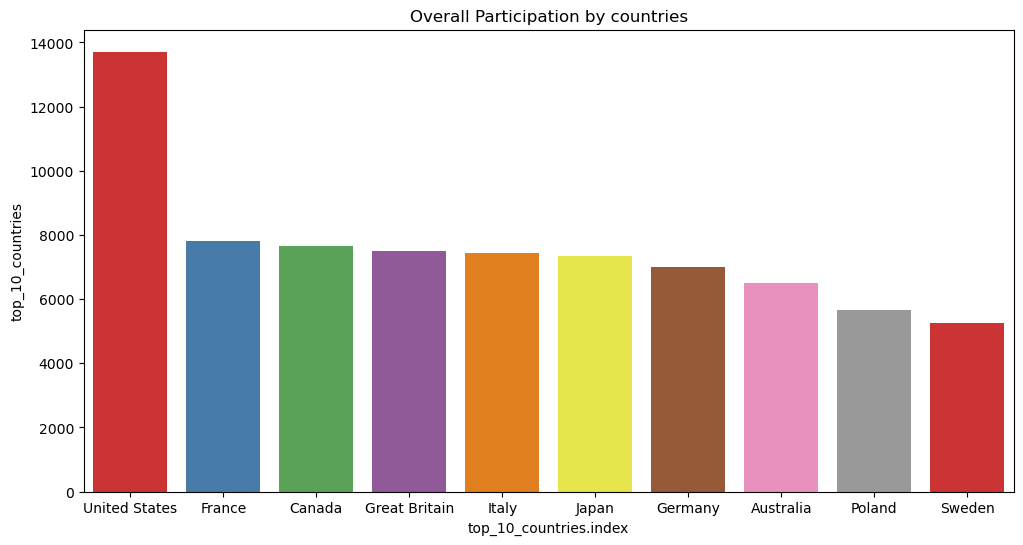

In [55]:
plt.figure(figsize=(12,6))
plt.title('Overall Participation by countries')
plt.xlabel('top_10_countries.index')
plt.ylabel('top_10_countries')
sns.barplot(x=top_10_countries.index,y=top_10_countries, palette='Set1')
plt.show()

##### 2.HISTOGRAM OF EXAM SCORE 

C:\Users\HP\AppData\Local\Temp\ipykernel_50500\3379989003.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Age'], kde=True, palette='Set2')


<Axes: xlabel='Age', ylabel='Count'>

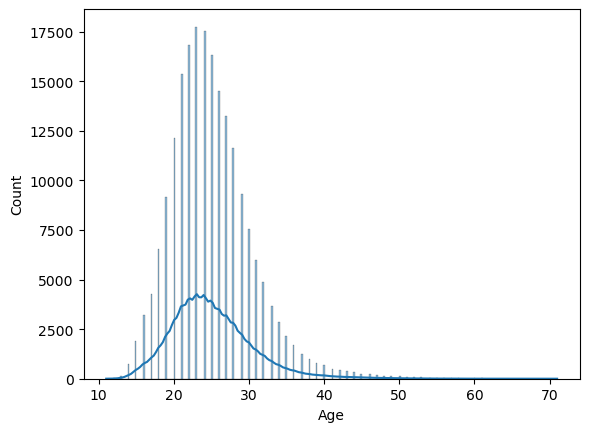

In [56]:
sns.histplot(df['Age'], kde=True, palette='Set2')

In [57]:
# The data shows it is well distributed on the histogram with majority of the data spread between 16-40
# which are usually the ages around which people are involved with athletics

##### 3.Pie Chart by Gender

In [58]:
gender_counts=df.Sex.value_counts()
gender_counts

Sex
M    139454
F     66711
Name: count, dtype: int64

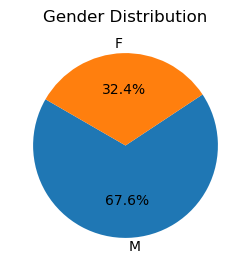

In [59]:
plt.figure(figsize=(3,3))
plt.title("Gender Distribution")
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',startangle=150); #shadow=True

##### 4.Summary Statistics/EDA in a table

In [60]:
# Summary statistics
summary=data.describe(include="all").T #.T makes it easier to read(rows = columns in data)

# Add extra insights
summary["mode"] = data.mode().iloc(0) # first mode if  multiple

print("\n Summary Statistics:\n")
summary


 Summary Statistics:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max,mode
ID,271116.0,NaN,NaN,NaN,68248.954396,39022.286345,1.0,34643.0,68205.0,102097.25,135571.0,<pandas.core.indexing._iLocIndexer object at 0...
Name,271116,134732,Robert Tait McKenzie,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<pandas.core.indexing._iLocIndexer object at 0...
Sex,271116,2,M,196594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<pandas.core.indexing._iLocIndexer object at 0...
Age,261642.0,NaN,NaN,NaN,25.556898,6.393561,10.0,21.0,24.0,28.0,97.0,<pandas.core.indexing._iLocIndexer object at 0...
Height,210945.0,NaN,NaN,NaN,175.33897,10.518462,127.0,168.0,175.0,183.0,226.0,<pandas.core.indexing._iLocIndexer object at 0...
Weight,208241.0,NaN,NaN,NaN,70.702393,14.34802,25.0,60.0,70.0,79.0,214.0,<pandas.core.indexing._iLocIndexer object at 0...
Team,271116,1184,United States,17847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<pandas.core.indexing._iLocIndexer object at 0...
NOC,271116,230,USA,18853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<pandas.core.indexing._iLocIndexer object at 0...
Games,271116,51,2000 Summer,13821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<pandas.core.indexing._iLocIndexer object at 0...
Year,271116.0,NaN,NaN,NaN,1978.37848,29.877632,1896.0,1960.0,1988.0,2002.0,2016.0,<pandas.core.indexing._iLocIndexer object at 0...


In [62]:
# Top ten countries participating
top_10_sports=df['Sport'].value_counts().sort_values(ascending=False).head(10)

In [63]:
top_10_sports

Sport
Athletics               32374
Swimming                18776
Gymnastics              18271
Rowing                   7790
Cycling                  7775
Cross Country Skiing     7529
Shooting                 7260
Fencing                  6537
Alpine Skiing            6322
Canoeing                 5550
Name: count, dtype: int64

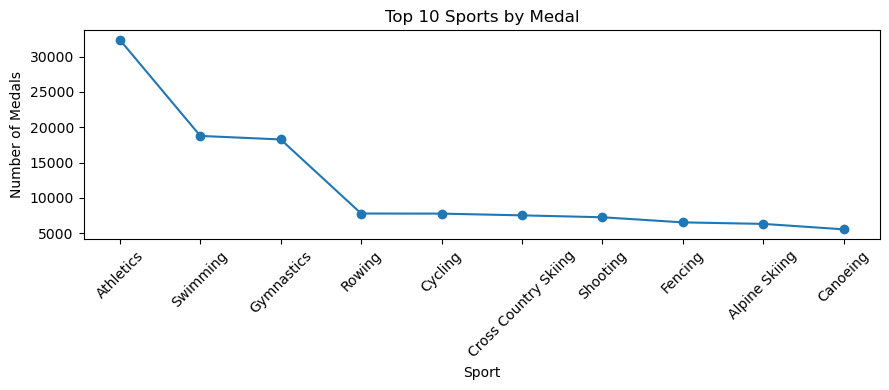

In [64]:
# Create a line chart
plt.figure(figsize=(9,4))
plt.plot(top_10_sports,  marker='o')
plt.title('Top 10 Sports by Medal')
plt.xlabel('Sport')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()